In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib.ticker as mticker


In [2]:
# Setting up the data
df = pd.read_excel('Cleaned_data.xlsx')
df.columns = ['Date', 'Price']


df_paper = df[(df['Date'] >= '2018-03-12') & (df['Date'] <= '2022-02-14')].reset_index(drop=True)
df_paper

,Date,Price
0,2018-03-12,61.35
1,2018-03-13,60.69
2,2018-03-14,60.89
3,2018-03-15,61.16
4,2018-03-16,62.29
...,...,...
980,2022-02-08,89.32
981,2022-02-09,89.57
982,2022-02-10,89.83
983,2022-02-11,93.10


In [3]:
# Train and Test split, ~75/25 split
train = df_paper['Date'] <= '2021-02-23'
test  = df_paper['Date'] >= '2021-02-24'

print("Train: ", len(train), " Test: ", len(test), "Total: ", len(df_paper))
prices     = df_paper['Price'].values
dates      = df_paper['Date'].values

Train:  985  Test:  985 Total:  985


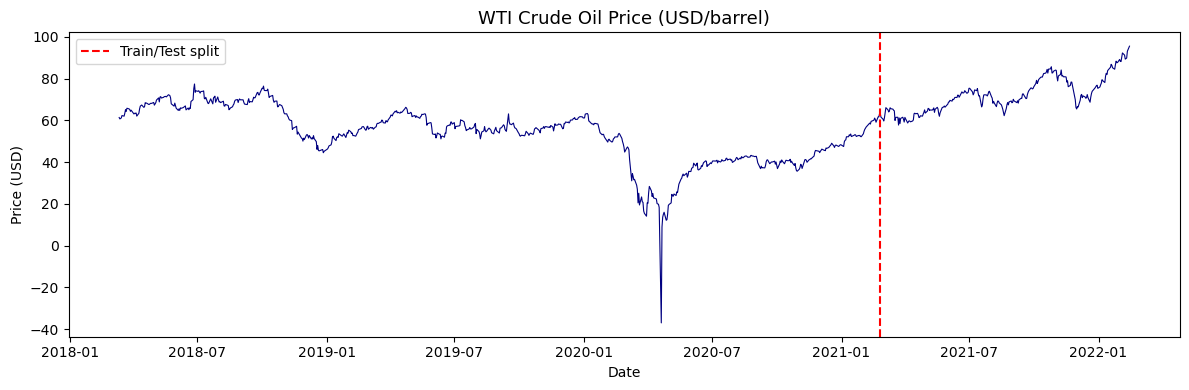

In [4]:
# Plotting the train and test Data
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_paper['Date'], prices, color='navy', linewidth=0.8)
ax.axvline(pd.Timestamp('2021-02-24'), color='red', linestyle='--', label='Train/Test split')
ax.set_title('WTI Crude Oil Price (USD/barrel)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.legend(); plt.tight_layout()
plt.show()


Max reconstruction error: 0.00000000


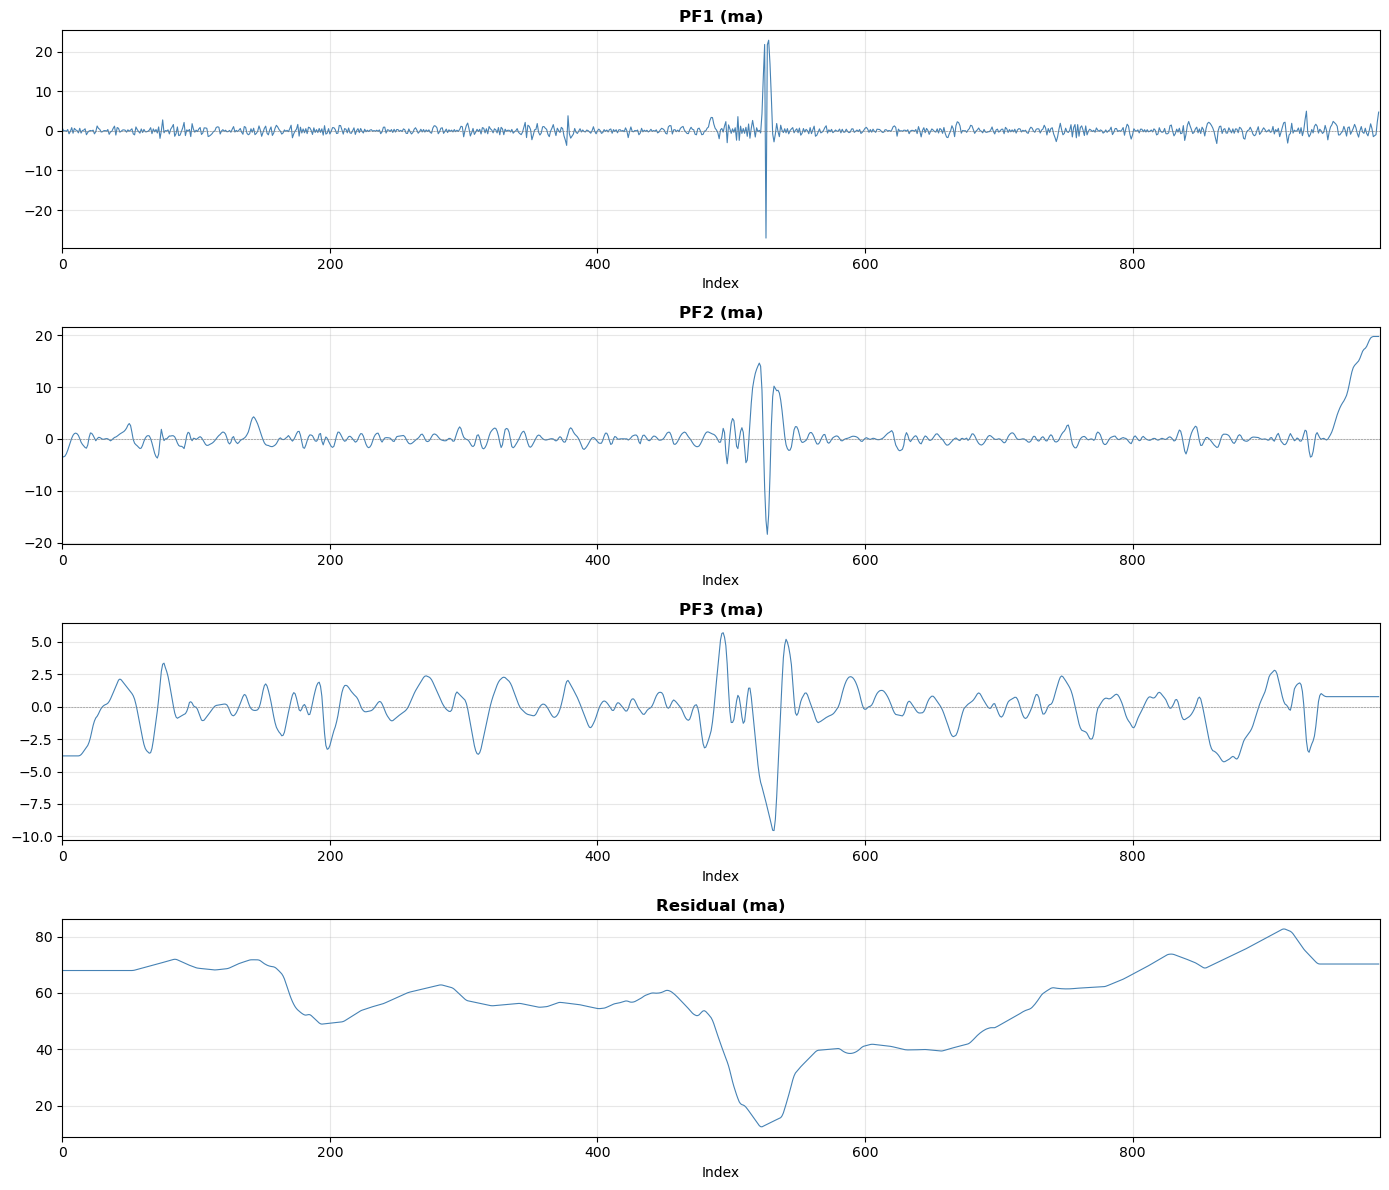

In [5]:
def moving_average(x, window):
    if w <= 1:
        return x.copy()
    pad = window // 2
    x_pad = np.pad(x, pad, mode='edge')
    return np.convolve(x_pad, np.ones(window)/window, mode='valid')[:len(x)]



prices = df_paper['Price'].values
n = len(prices)

# moving average
def moving_average(x, w):
    if w <= 1: return x.copy()
    pad = w // 2
    xp  = np.pad(x, pad, mode='edge')
    return np.convolve(xp, np.ones(w)/w, mode='valid')[:len(x)]


# single extraction
def extract_one_pf(signal, w=3, max_iter=30, tol=0.001):
    n      = len(signal)
    h      = signal.copy().astype(float)
    a_prod = np.ones(n)

    for _ in range(max_iter):
        ext_idx = np.array([i for i in range(1, n-1)
                             if (h[i]>h[i-1] and h[i]>h[i+1]) or
                                (h[i]<h[i-1] and h[i]<h[i+1])])
        if len(ext_idx) < 2:
            break

        ext_val = h[ext_idx]
        mid_x   = (ext_idx[:-1] + ext_idx[1:]) / 2.0
        m_mid   = (ext_val[:-1] + ext_val[1:]) / 2.0
        a_mid   = np.abs(ext_val[:-1] - ext_val[1:]) / 2.0

        full  = np.arange(n, dtype=float)
        bnd_x = np.concatenate([[0.0],      mid_x,    [float(n-1)]])
        bnd_m = np.concatenate([[m_mid[0]], m_mid,    [m_mid[-1]]])
        bnd_a = np.concatenate([[a_mid[0]], a_mid,    [a_mid[-1]]])

        m_s = moving_average(np.interp(full, bnd_x, bnd_m), w)
        a_s = moving_average(np.interp(full, bnd_x, bnd_a), w)
        a_s = np.maximum(a_s, 1e-10)

        h_new  = (h - m_s) / a_s
        a_prod = a_prod * a_s

        ext2 = np.array([i for i in range(1, n-1)
                          if (h_new[i]>h_new[i-1] and h_new[i]>h_new[i+1]) or
                             (h_new[i]<h_new[i-1] and h_new[i]<h_new[i+1])])
        if len(ext2) > 1:
            if np.mean(np.abs(np.abs(h_new[ext2]) - 1.0)) < tol:
                h = h_new
                break
        h = h_new

    return a_prod * h


# LMD decomposer
def lmd_decompose(signal, n_pf=3, ma_window=3, max_iter=30, tol=0.001):
    """
    Decomposes signal into n_pf Product Functions + Residual.
    
    The residual is extracted LAST as the remaining monotonic trend.
    PF1 = high-frequency, PF2 = medium, PF3 = slow oscillation.
    """
    residual = signal.copy().astype(float)
    pfs = []

    for k in range(n_pf):
        pf = extract_one_pf(residual, w=ma_window,
                            max_iter=max_iter, tol=tol)
        if not np.all(np.isfinite(pf)):
            print(f"PF{k+1}: non-finite — stopping.")
            break
        pfs.append(pf)
        residual = residual - pf

        n_ext = sum(1 for i in range(1, len(residual)-1)
                    if (residual[i]>residual[i-1] and residual[i]>residual[i+1]) or
                       (residual[i]<residual[i-1] and residual[i]<residual[i+1]))
        # print(f"PF{k+1}: [{pf.min():.3f}, {pf.max():.3f}] | "
        #       f"residual extrema: {n_ext}")
        if n_ext < 2:
            print("  → Residual monotonic, stopping.")
            break

    return pfs, residual


# LMD decomposition on crude oil prices
pfs, residual = lmd_decompose(prices, n_pf=3, ma_window=3,
                               max_iter=30, tol=0.001)



# sanity check on the signals
reconstruction = sum(pfs) + residual
print(f"\nMax reconstruction error: {np.max(np.abs(reconstruction - prices)):.8f}")


# Plots
n_plots = len(pfs) + 1   # PFs + Residual
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3*n_plots))

for i, pf in enumerate(pfs):
    axes[i].plot(pf, linewidth=0.8, color='steelblue')
    axes[i].set_title(f'PF{i+1} (ma)', fontweight='bold', fontsize=12)
    axes[i].axhline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[i].set_xlim(0, len(prices))
    axes[i].grid(True, alpha=0.3)

axes[-1].plot(residual, linewidth=0.8, color='steelblue')
axes[-1].set_title('Residual (ma)', fontweight='bold', fontsize=12)
axes[-1].set_xlim(0, len(prices))
axes[-1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('Index')

plt.tight_layout()
plt.show()

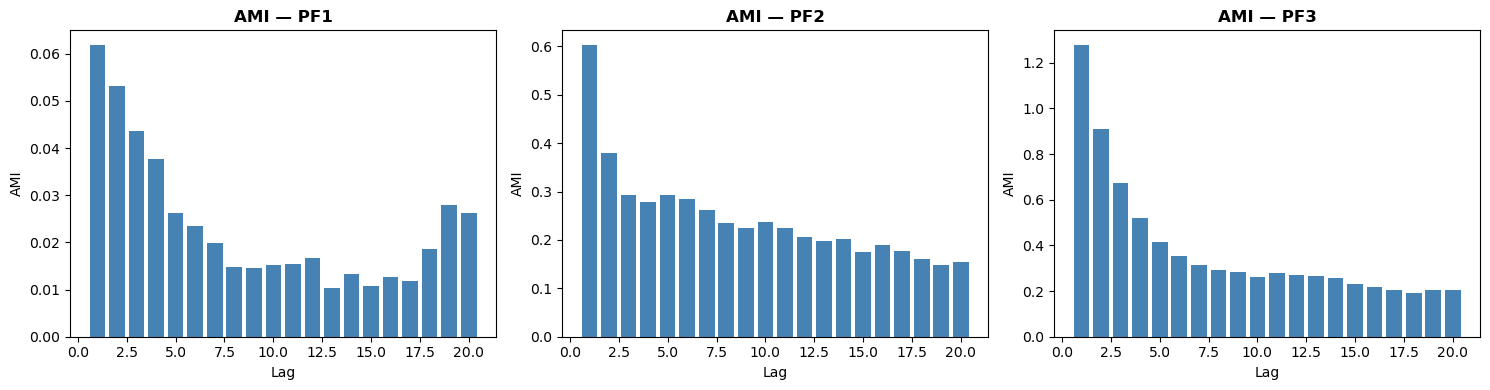

PF1 (stochastic):    [-27.070, 22.856]
VPF (deterministic): [-12.795, 90.795]
PF1 + VPF == prices: True


In [6]:
# AMI to classify PFs as stochastic vs deterministic
def compute_ami(x, max_lag=20, bins=20):
    from scipy.stats import entropy
    ami = []
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        hist2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        hist2d = hist2d / hist2d.sum()
        px = hist2d.sum(axis=1)
        py = hist2d.sum(axis=0)
        hx  = entropy(px + 1e-12)
        hy  = entropy(py + 1e-12)
        hxy = entropy(hist2d.flatten() + 1e-12)
        ami.append(hx + hy - hxy)
    return np.array(ami)

# compute for each PF
ami_results = {f'PF{i+1}': compute_ami(pf, max_lag=20) for i, pf in enumerate(pfs)}

fig, axes = plt.subplots(1, len(pfs), figsize=(5*len(pfs), 4))
for i, (name, ami) in enumerate(ami_results.items()):
    axes[i].bar(range(1, 21), ami, color='steelblue')
    axes[i].set_title(f'AMI — {name}', fontweight='bold')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('AMI')

plt.tight_layout()
plt.show()

# Classification: fast-decaying AMI = stochastic (PF1), rest = deterministic
PF1 = pfs[0]                          # stochastic
VPF = pfs[1] + pfs[2] + residual      # deterministic (PF2 + PF3 + residual)

print(f"PF1 (stochastic):    [{PF1.min():.3f}, {PF1.max():.3f}]")
print(f"VPF (deterministic): [{VPF.min():.3f}, {VPF.max():.3f}]")
print(f"PF1 + VPF == prices: {np.allclose(PF1 + VPF, prices)}")

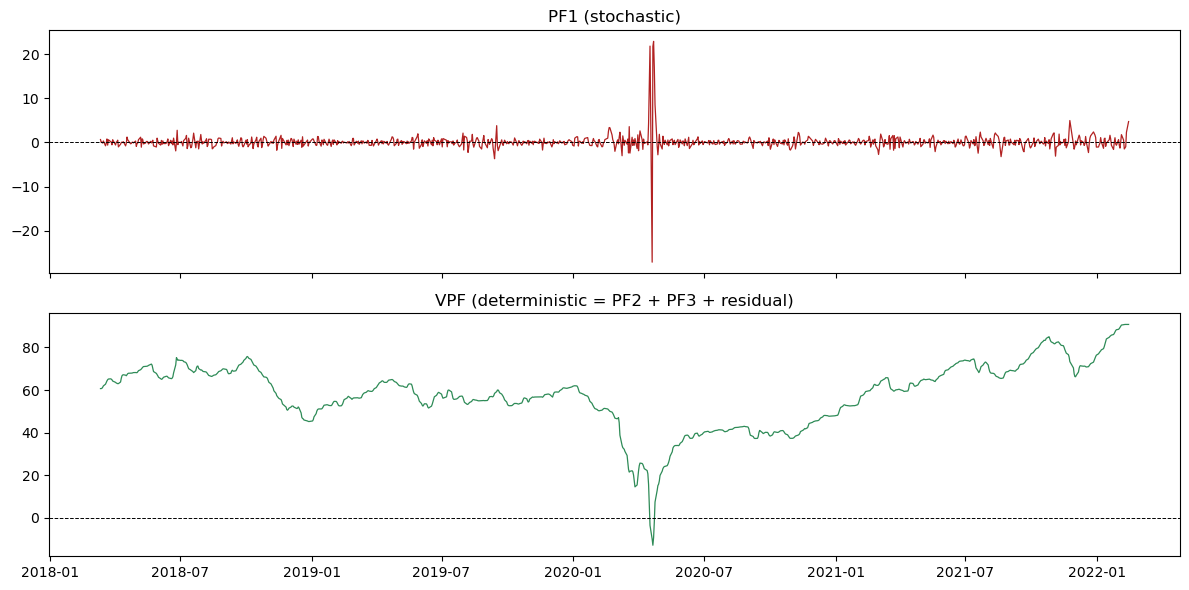

In [7]:
df_paper['PF1_stoch'] = PF1
df_paper['VPF_det']  = VPF

df_paper[['Date', 'Price', 'PF1_stoch', 'VPF_det']].head()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_paper['Date'], df_paper['PF1_stoch'], color='firebrick', linewidth=0.9)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[0].set_title('PF1 (stochastic)', fontsize=12)

axes[1].plot(df_paper['Date'], df_paper['VPF_det'], color='seagreen', linewidth=0.9)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[1].set_title('VPF (deterministic = PF2 + PF3 + residual)', fontsize=12)

plt.tight_layout()

plt.show()

TABLE 1. ADF and PP test values (WTI, all PFs, and VPF)

Time Horizon        PF1-ADF     PF1-PP    VPF-ADF     VPF-PP
──────────────────────────────────────────────────────────────
5 days ahead        -12.288   -118.935     -6.886     -6.744
                 (0.000)*  (0.000)*  (0.000)*  (0.000)*

10 days ahead       -12.288   -118.935    -10.731    -14.404
                 (0.000)*  (0.000)*  (0.000)*  (0.000)*

15 days ahead       -12.288   -118.935    -10.731    -14.404
                 (0.000)*  (0.000)*  (0.000)*  (0.000)*



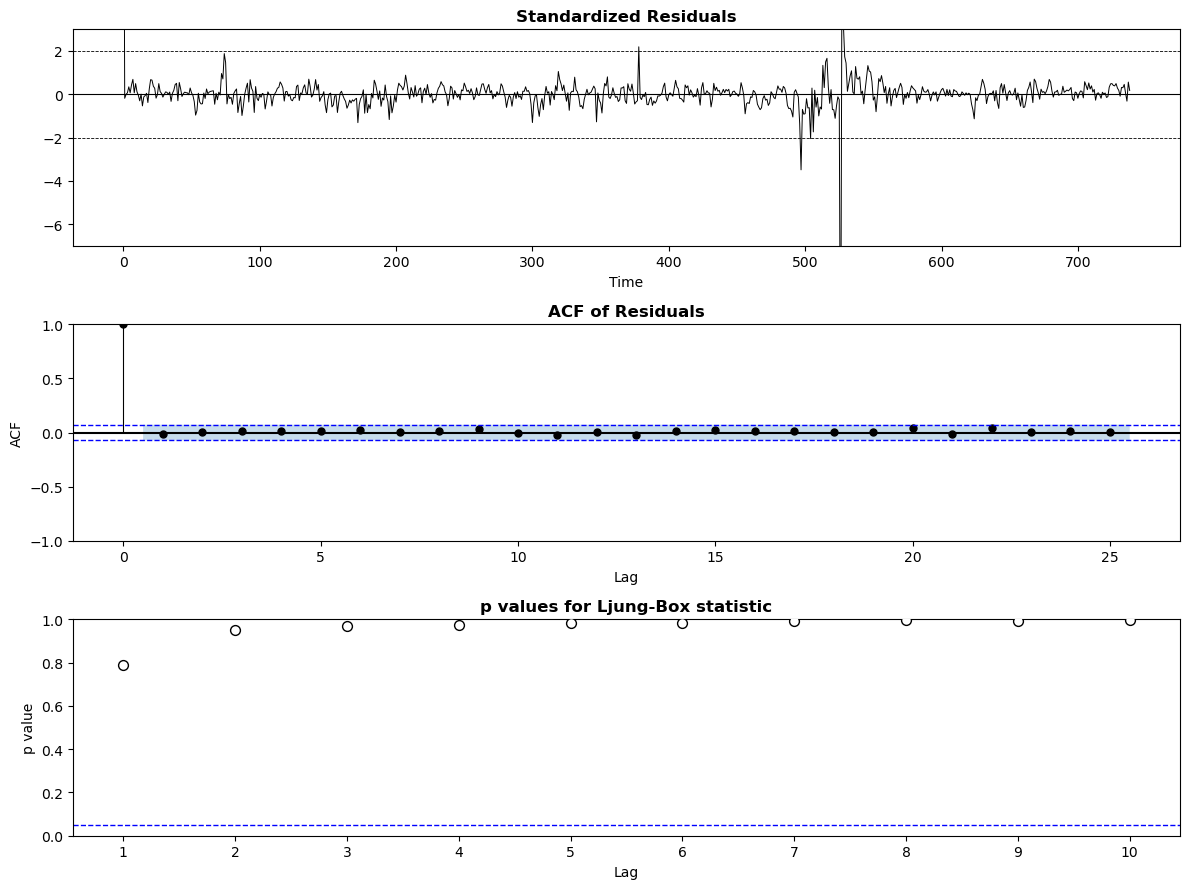

In [8]:
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf


#  Table 1: ADF and PP on PF1 and VPF   
# d=1 for PF1 at all horizons
# d=1 for VPF at 5-day, d=2 for VPF at 10 and 15-day (as per paper)

def adf(series, d=0):
    s = series.copy()
    for _ in range(d): s = np.diff(s)
    r = adfuller(s, autolag='AIC')
    return r[0], r[1]

def pp(series, d=0):
    s = series.copy()
    for _ in range(d): s = np.diff(s)
    r = PhillipsPerron(s)
    return r.stat, r.pvalue

configs = {
    '5 days ahead':  {'pf1_d': 1, 'vpf_d': 1},
    '10 days ahead': {'pf1_d': 1, 'vpf_d': 2},
    '15 days ahead': {'pf1_d': 1, 'vpf_d': 2},
}

print("TABLE 1. ADF and PP test values (WTI, all PFs, and VPF)")
print(f"\n{'Time Horizon':<16} {'PF1-ADF':>10} {'PF1-PP':>10} {'VPF-ADF':>10} {'VPF-PP':>10}")
print('─' * 62)


PF1_train = df_paper['PF1_stoch'][train]
VPF_train = df_paper['VPF_det'][train]

train_idx = df_paper[train].index.tolist()
test_idx  = df_paper[test].index.tolist()


for horizon, cfg in configs.items():
    adf_pf1, p1 = adf(PF1_train, d=cfg['pf1_d'])
    pp_pf1,  p2 = pp(PF1_train,  d=cfg['pf1_d'])
    adf_vpf, p3 = adf(VPF_train, d=cfg['vpf_d'])
    pp_vpf,  p4 = pp(VPF_train,  d=cfg['vpf_d'])
    print(f"{horizon:<16} {adf_pf1:>10.3f} {pp_pf1:>10.3f} {adf_vpf:>10.3f} {pp_vpf:>10.3f}")
    print(f"{'':16} ({p1:.3f})*  ({p2:.3f})*  ({p3:.3f})*  ({p4:.3f})*\n")


#  Figure 6: ARIMA(2,1,3) diagnostics on WTI    
fit_wti   = ARIMA(prices[train], order=(2,1,3)).fit()
resid     = fit_wti.resid
std_resid = resid / resid.std()
lb        = acorr_ljungbox(resid, lags=range(1, 11), return_df=True)
n         = len(resid)
ci        = 1.96 / np.sqrt(n)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(std_resid, color='black', linewidth=0.7)
axes[0].axhline( 0, color='black', linewidth=0.8)
axes[0].axhline( 2, color='black', linewidth=0.6, linestyle='--')
axes[0].axhline(-2, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('Standardized Residuals', fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylim(-7, 3)

plot_acf(resid, lags=25, ax=axes[1], color='black',
         vlines_kwargs={'colors': 'black', 'linewidth': 0.8})
axes[1].set_title('ACF of Residuals', fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
for line in axes[1].lines:
    line.set_color('black')
axes[1].axhline( ci, color='blue', linestyle='--', linewidth=1)
axes[1].axhline(-ci, color='blue', linestyle='--', linewidth=1)

axes[2].scatter(lb.index, lb['lb_pvalue'], color='white', edgecolors='black', s=50, zorder=3)
axes[2].axhline(0.05, color='blue', linestyle='--', linewidth=1)
axes[2].set_title('p values for Ljung-Box statistic', fontweight='bold')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('p value')
axes[2].set_ylim(0, 1.0)
axes[2].set_xticks(range(1, 11))

plt.tight_layout()

plt.show()

In [9]:
# XGBOOST
from pmdarima import auto_arima
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error


n_test  = len(test_idx)   
n_train = len(train_idx) 

# ARIMA orders from paper (Table 2)
# These are the best orders the paper found via auto_arima
ARIMA_ORDERS = {
    5:  {'PF1': (1,1,1), 'VPF': (2,1,2)},
    10: {'PF1': (1,1,1), 'VPF': (1,2,2)},
    15: {'PF1': (2,1,1), 'VPF': (1,2,2)},
}

# Lag features for XGBoost
def make_lag_features(series, n_lags=10):
    df_lag = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df_lag[f'lag_{lag}'] = df_lag['y'].shift(lag)
    df_lag.dropna(inplace=True)
    return df_lag.drop('y', axis=1).values, df_lag['y'].values

# Rolling multi-step forecast for ARIMA
def arima_rolling_forecast(train, horizon, order):
    """
    True h-step-ahead rolling forecast:
    At each step t, fit ARIMA on history up to t,
    forecast h steps ahead, record the h-th value.
    Then append the TRUE next value (not forecast) to history — 
    so each forecast is genuinely h steps ahead from observed data.
    """
    # actual_test is available globally
    history = list(train)
    preds   = []
    for i in range(n_test):
        fit  = ARIMA(history, order=order).fit(
                   method_kwargs={"warn_convergence": False})
        yhat = fit.forecast(steps=horizon)[-1]   # h-step ahead value
        preds.append(yhat)
        history.append(prices[test_idx[i]])      # append TRUE observed value
    return np.array(preds)

# Main loop
results_all = {}   # stores forecasts and metrics per horizon
xgb_params  = {'max_depth': 7, 'learning_rate': 0.3,
                'n_estimators': 30, 'objective': 'reg:squarederror',
                'verbosity': 0}

for h in [5, 10, 15]:
    print(f"\n{'='*55}")
    print(f"  Horizon: {h} days ahead")
    print(f"{'='*55}")

    pf1_order = ARIMA_ORDERS[h]['PF1']
    vpf_order = ARIMA_ORDERS[h]['VPF']

    # Step 1: Fit ARIMA on PF1 and VPF (training data)
    print(f"  Fitting ARIMA{pf1_order} on PF1 ...")
    fit_pf1 = ARIMA(PF1_train, order=pf1_order).fit(
        method_kwargs={"warn_convergence": False})

    print(f"  Fitting ARIMA{vpf_order} on VPF ...")
    fit_vpf = ARIMA(VPF_train, order=vpf_order).fit(
        method_kwargs={"warn_convergence": False})

    # Step 2: In-sample ARIMA residuals (for XGBoost training)
    lmd_sd_arima_train_fit = fit_pf1.fittedvalues + fit_vpf.fittedvalues
    actual_train           = PF1_train + VPF_train  # = prices[train_idx]
    train_resid            = actual_train - lmd_sd_arima_train_fit

    print(f"  Train residual — mean: {train_resid.mean():.4f}  std: {train_resid.std():.4f}")

    # Step 3: Train XGBoost on residuals
    N_LAGS = 10
    X_tr, y_tr = make_lag_features(train_resid.values, n_lags=N_LAGS)
    xgb_model  = xgb.XGBRegressor(**xgb_params)
    xgb_model.fit(X_tr, y_tr)

    # XGBoost in-sample (train) predicted residuals
    xgb_train_pred = xgb_model.predict(X_tr)

    # Step 4: Rolling ARIMA forecast on test
    print(f"  Rolling ARIMA forecast on test ({n_test} steps) ...")
    arima_pf1_test = arima_rolling_forecast(PF1_train, h, pf1_order)
    arima_vpf_test = arima_rolling_forecast(VPF_train, h, vpf_order)
    lmd_sd_arima_test = arima_pf1_test + arima_vpf_test

    # Step 5: XGBoost rolling forecast on test residuals
    history_resid = list(train_resid.values)
    xgb_test_pred = []
    for _ in range(n_test):
        window = history_resid[-N_LAGS:]
        x_in   = np.array(window[::-1]).reshape(1, -1)
        pred   = xgb_model.predict(x_in)[0]
        xgb_test_pred.append(pred)
        history_resid.append(pred)
    xgb_test_pred = np.array(xgb_test_pred)

    # Step 6: Final hybrid forecast 
    final_forecast = lmd_sd_arima_test + xgb_test_pred
    actual_test    = prices[test_idx]

    # Metrics
    def rmse(a, f): return np.sqrt(mean_squared_error(a, f))
    def mae(a, f):  return mean_absolute_error(a, f)
    def mape(a, f):
        a, f = np.array(a), np.array(f)
        return np.mean(np.abs((a - f) / a)) * 100
    def ds(a, f):
        a, f = np.array(a), np.array(f)
        return np.mean(np.sign(np.diff(a)) == np.sign(np.diff(f))) * 100

    print(f"\n  ── LMD-ARIMA-SD-XGBoost ({h}-day) ──")
    print(f"  RMSE : {rmse(actual_test, final_forecast):.4f}")
    print(f"  MAE  : {mae(actual_test,  final_forecast):.4f}")
    print(f"  MAPE : {mape(actual_test, final_forecast):.4f}")
    print(f"  DS   : {ds(actual_test,   final_forecast):.2f}%")

    #  Store everything for later tables/plots
    results_all[h] = {
        'fit_pf1':             fit_pf1,
        'fit_vpf':             fit_vpf,
        'train_resid':         train_resid,
        'xgb_model':           xgb_model,
        'xgb_train_pred':      xgb_train_pred,
        'xgb_train_idx_start': N_LAGS,  # lag features drop first N_LAGS obs
        'lmd_sd_arima_test':   lmd_sd_arima_test,
        'xgb_test_pred':       xgb_test_pred,
        'final_forecast':      final_forecast,
        'actual_test':         actual_test,
    }

print("\XGBoost training complete for all 3 horizons.")

<>:136: SyntaxWarning: invalid escape sequence '\X'
<>:136: SyntaxWarning: invalid escape sequence '\X'
C:\Users\Akash\AppData\Local\Temp\ipykernel_16812\4108272568.py:136: SyntaxWarning: invalid escape sequence '\X'
  print("\XGBoost training complete for all 3 horizons.")



  Horizon: 5 days ahead
  Fitting ARIMA(1, 1, 1) on PF1 ...
  Fitting ARIMA(2, 1, 2) on VPF ...
  Train residual — mean: 0.0884  std: 3.1135
  Rolling ARIMA forecast on test (246 steps) ...

  ── LMD-ARIMA-SD-XGBoost (5-day) ──
  RMSE : 71.8808
  MAE  : 71.0011
  MAPE : 98.3079
  DS   : 54.29%

  Horizon: 10 days ahead
  Fitting ARIMA(1, 1, 1) on PF1 ...
  Fitting ARIMA(1, 2, 2) on VPF ...
  Train residual — mean: 0.0461  std: 3.3366
  Rolling ARIMA forecast on test (246 steps) ...


c:\Users\Akash\miniconda3\envs\ML\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



  ── LMD-ARIMA-SD-XGBoost (10-day) ──
  RMSE : 71.9026
  MAE  : 70.9980
  MAPE : 98.2765
  DS   : 54.29%

  Horizon: 15 days ahead
  Fitting ARIMA(2, 1, 1) on PF1 ...
  Fitting ARIMA(1, 2, 2) on VPF ...
  Train residual — mean: 0.0450  std: 3.3361
  Rolling ARIMA forecast on test (246 steps) ...


c:\Users\Akash\miniconda3\envs\ML\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



  ── LMD-ARIMA-SD-XGBoost (15-day) ──
  RMSE : 72.3235
  MAE  : 71.4440
  MAPE : 98.8964
  DS   : 54.69%
\XGBoost training complete for all 3 horizons.


In [10]:
#  Corrected rolling forecast: always 1-step-ahead 
def arima_rolling_forecast_1step(train_series, test_series, order):
    """
    True 1-step-ahead rolling forecast.
    At each step, fit on all history, forecast 1 step, 
    then append the ACTUAL observed value.
    """
    history = list(train_series)
    preds   = []
    for actual_val in test_series:
        fit  = ARIMA(history, order=order).fit(
                   method_kwargs={"warn_convergence": False})
        yhat = fit.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(actual_val)   # append TRUE value, not forecast
    return np.array(preds)

#  Horizon controls TEST WINDOW SIZE, not forecast steps 
HORIZON_DAYS = {5: 20, 10: 20, 15: 20}  # ~20 trading days shown in Table 4

#  Main loop 
results_all = {}

for h in [5, 10, 15]:
    print(f"\n{'='*55}")
    print(f"  Horizon: {h} days ahead")
    print(f"{'='*55}")

    pf1_order = ARIMA_ORDERS[h]['PF1']
    vpf_order = ARIMA_ORDERS[h]['VPF']

    PF1_test = PF1[test_idx]
    VPF_test = VPF[test_idx]

    #  Fit ARIMA on training data 
    print(f"  Fitting ARIMA{pf1_order} on PF1 ...")
    fit_pf1 = ARIMA(PF1_train, order=pf1_order).fit(
        method_kwargs={"warn_convergence": False})

    print(f"  Fitting ARIMA{vpf_order} on VPF ...")
    fit_vpf = ARIMA(VPF_train, order=vpf_order).fit(
        method_kwargs={"warn_convergence": False})

    #  In-sample residuals for XGBoost training 
    actual_train_combined = PF1_train + VPF_train
    train_fit_combined    = fit_pf1.fittedvalues + fit_vpf.fittedvalues
    train_resid           = actual_train_combined - train_fit_combined

    print(f"  Train residual — mean: {train_resid.mean():.4f}  std: {train_resid.std():.4f}")

    #  Train XGBoost on residuals 
    N_LAGS = 10
    X_tr, y_tr = make_lag_features(train_resid.values, n_lags=N_LAGS)
    xgb_model  = xgb.XGBRegressor(**xgb_params)
    xgb_model.fit(X_tr, y_tr)
    xgb_train_pred = xgb_model.predict(X_tr)

    #  1-step-ahead rolling ARIMA forecast on test
    print(f"  Rolling 1-step-ahead ARIMA forecast on test ({n_test} steps) ...")
    arima_pf1_test = arima_rolling_forecast_1step(PF1_train, PF1_test, pf1_order)
    arima_vpf_test = arima_rolling_forecast_1step(VPF_train, VPF_test, vpf_order)
    lmd_sd_arima_test = arima_pf1_test + arima_vpf_test

    #  XGBoost rolling forecast on test residuals 
    history_resid = list(train_resid.values)
    actual_resid_test = prices[test_idx] - lmd_sd_arima_test  # true residuals
    xgb_test_pred = []
    for true_resid in actual_resid_test:
        window = history_resid[-N_LAGS:]
        x_in   = np.array(window[::-1]).reshape(1, -1)
        pred   = xgb_model.predict(x_in)[0]
        xgb_test_pred.append(pred)
        history_resid.append(true_resid)   # append TRUE residual
    xgb_test_pred = np.array(xgb_test_pred)

    #  Final hybrid forecast
    final_forecast = lmd_sd_arima_test + xgb_test_pred
    actual_test    = prices[test_idx]

    print(f"\n  ── LMD-ARIMA-SD-XGBoost ({h}-day) ──")
    print(f"  RMSE : {rmse(actual_test, final_forecast):.4f}")
    print(f"  MAE  : {mae(actual_test,  final_forecast):.4f}")
    print(f"  MAPE : {mape(actual_test, final_forecast):.4f}%")
    print(f"  DS   : {ds(actual_test,   final_forecast):.2f}%")

    results_all[h] = {
        'fit_pf1': fit_pf1, 'fit_vpf': fit_vpf,
        'train_resid': train_resid,
        'xgb_model': xgb_model,
        'xgb_train_pred': xgb_train_pred,
        'lmd_sd_arima_test': lmd_sd_arima_test,
        'xgb_test_pred': xgb_test_pred,
        'final_forecast': final_forecast,
        'actual_test': actual_test,
        'actual_resid_test': actual_resid_test,
    }

print("\n Done.")


  Horizon: 5 days ahead
  Fitting ARIMA(1, 1, 1) on PF1 ...
  Fitting ARIMA(2, 1, 2) on VPF ...
  Train residual — mean: 0.0884  std: 3.1135
  Rolling 1-step-ahead ARIMA forecast on test (246 steps) ...

  ── LMD-ARIMA-SD-XGBoost (5-day) ──
  RMSE : 1.1662
  MAE  : 0.8852
  MAPE : 1.2349%
  DS   : 64.49%

  Horizon: 10 days ahead
  Fitting ARIMA(1, 1, 1) on PF1 ...
  Fitting ARIMA(1, 2, 2) on VPF ...
  Train residual — mean: 0.0461  std: 3.3366
  Rolling 1-step-ahead ARIMA forecast on test (246 steps) ...

  ── LMD-ARIMA-SD-XGBoost (10-day) ──
  RMSE : 1.2046
  MAE  : 0.9033
  MAPE : 1.2648%
  DS   : 62.86%

  Horizon: 15 days ahead
  Fitting ARIMA(2, 1, 1) on PF1 ...
  Fitting ARIMA(1, 2, 2) on VPF ...
  Train residual — mean: 0.0450  std: 3.3361
  Rolling 1-step-ahead ARIMA forecast on test (246 steps) ...

  ── LMD-ARIMA-SD-XGBoost (15-day) ──
  RMSE : 1.2310
  MAE  : 0.9300
  MAPE : 1.3028%
  DS   : 61.22%

 Done.


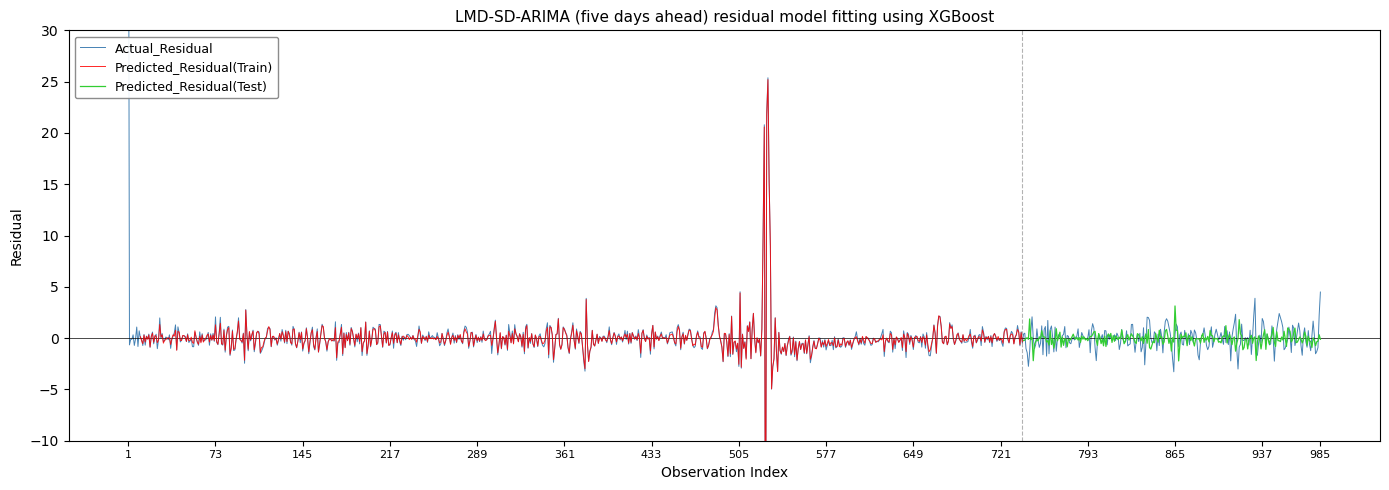

FIGURE 12. "LMD-SD-ARIMA" (five days ahead) residual_model fitting using XGBOOST model.



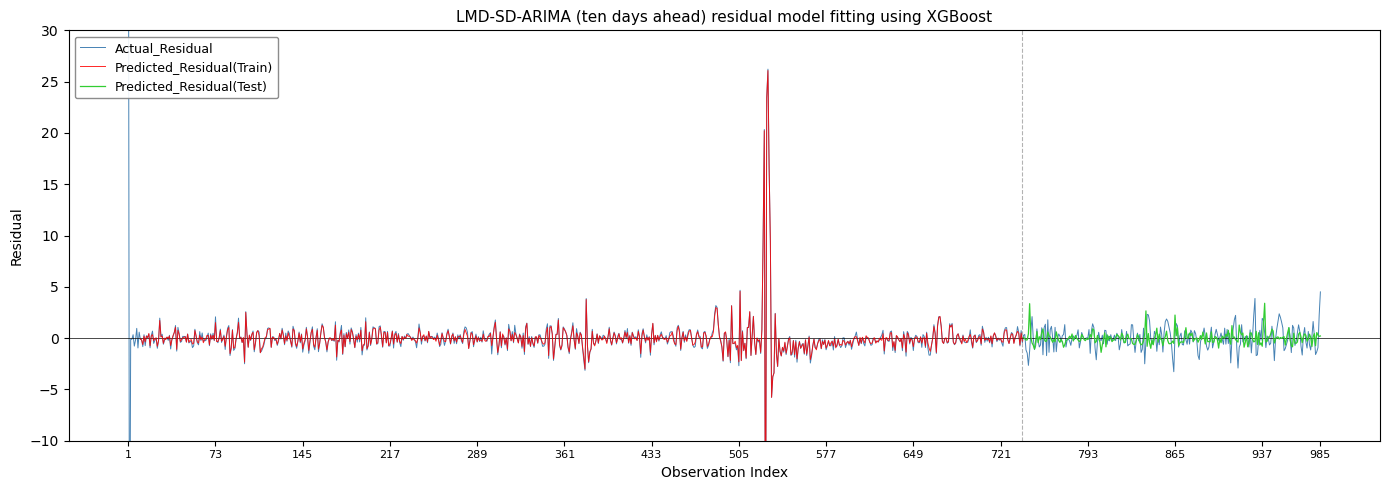

FIGURE 13. "LMD-SD-ARIMA" (ten days ahead) residual_model fitting using XGBOOST model.



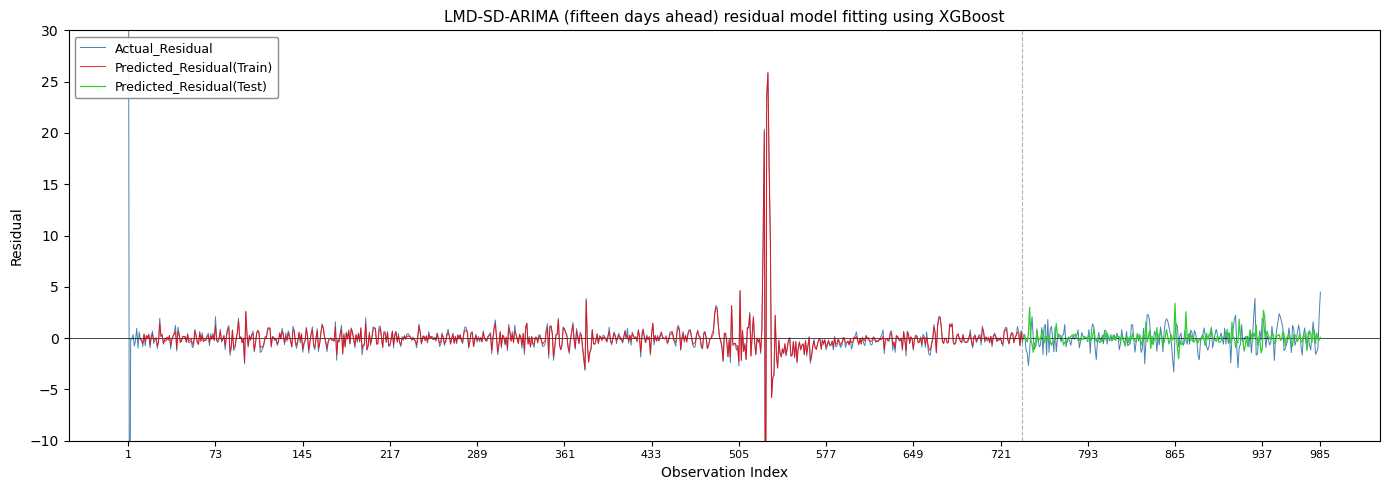

FIGURE 14. "LMD-SD-ARIMA" (fifteen days ahead) residual model fitting using XGBOOST model.



In [11]:
#  Figures 12, 13, 14: XGBoost Residual Fitting Plots 
# Shows: Actual residual (full series) vs XGBoost predicted (train + test)

fig_titles = {
    5:  'FIGURE 12. "LMD-SD-ARIMA" (five days ahead) residual_model fitting using XGBOOST model.',
    10: 'FIGURE 13. "LMD-SD-ARIMA" (ten days ahead) residual_model fitting using XGBOOST model.',
    15: 'FIGURE 14. "LMD-SD-ARIMA" (fifteen days ahead) residual model fitting using XGBOOST model.',
}

for h in [5, 10, 15]:
    r = results_all[h]

    #  Build full actual residual series 
    # train residual: actual - ARIMA fit (length = n_train)
    # test residual:  actual - ARIMA forecast (length = n_test)
    train_resid_vals = r['train_resid'].values          # shape (n_train,)
    test_resid_vals  = r['actual_resid_test']           # shape (n_test,)
    actual_resid_full = np.concatenate([train_resid_vals, test_resid_vals])

    #  XGBoost predicted residuals 
    # train: predicted from lag features (starts at index N_LAGS due to lag creation)
    N_LAGS = 10
    xgb_train_full = np.full(len(train_resid_vals), np.nan)
    xgb_train_full[N_LAGS:] = r['xgb_train_pred']      # first N_LAGS are NaN

    xgb_test_full  = np.full(len(test_resid_vals), np.nan)
    xgb_test_full  = r['xgb_test_pred']

    #  x-axis: observation index across full series 
    x_full  = np.arange(1, len(actual_resid_full) + 1)
    x_train = np.arange(1, len(train_resid_vals) + 1)
    x_test  = np.arange(len(train_resid_vals) + 1,
                         len(train_resid_vals) + len(test_resid_vals) + 1)

    #  Plot 
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(x_full, actual_resid_full,
            color='steelblue', linewidth=0.7, label='Actual_Residual', zorder=2)

    ax.plot(x_train[N_LAGS:], r['xgb_train_pred'],
            color='red', linewidth=0.7, label='Predicted_Residual(Train)',
            alpha=0.85, zorder=3)

    ax.plot(x_test, r['xgb_test_pred'],
            color='limegreen', linewidth=0.9, label='Predicted_Residual(Test)',
            zorder=4)

    ax.axvline(len(train_resid_vals), color='gray',
               linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

    ax.set_ylim(-10, 30)
    ax.set_ylabel('Residual')
    ax.set_xlabel('Observation Index')
    ax.legend(loc='upper left', fontsize=9,
              framealpha=0.9, edgecolor='gray')
    ax.set_title(f'LMD-SD-ARIMA ({["five","ten","fifteen"][[5,10,15].index(h)]} days ahead)'
                 f' residual model fitting using XGBoost', fontsize=11)

    # x-ticks matching paper style (every ~50 obs)
    tick_positions = list(range(1, len(actual_resid_full), 72)) + [len(actual_resid_full)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_positions, fontsize=8)

    plt.tight_layout()
    fname = f'fig{[12,13,14][[5,10,15].index(h)]}_xgb_residual_{h}day.png'
    
    plt.show()
    print(fig_titles[h])
    print()

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

#  Table 2: ARIMA accuracy on PF1 and VPF per horizon 

def mase(actual, fitted, train_actual):
    """Mean Absolute Scaled Error."""
    mae_model = np.mean(np.abs(np.array(actual) - np.array(fitted)))
    naive_mae  = np.mean(np.abs(np.diff(np.array(train_actual))))
    return mae_model / naive_mae

print("TABLE 2. Measures of all VPF, PFs, and WTI crude oil prices' accuracy.")
print(f"\n{'Horizon':<10} {'Series':<6} {'Order':<10} {'MAE':>8} {'MAPE':>8} "
      f"{'RMSE':>8} {'MASE':>6} {'AIC':>12} {'L-B (p)':>16}")
print('─' * 95)

for h in [5, 10, 15]:
    r         = results_all[h]
    fit_pf1   = r['fit_pf1']
    fit_vpf   = r['fit_vpf']
    pf1_order = ARIMA_ORDERS[h]['PF1']
    vpf_order = ARIMA_ORDERS[h]['VPF']

    label = f"{h}-day"

    for name, fit, train_s in [('PF1', fit_pf1, PF1_train),
                                ('VPF', fit_vpf, VPF_train)]:

        actual  = np.array(train_s)
        fitted  = fit.fittedvalues
        resid   = fit.resid

        # align lengths (ARIMA drops initial obs due to differencing)
        min_len = min(len(actual), len(fitted))
        actual  = actual[-min_len:]
        fitted  = np.array(fitted)[-min_len:]
        resid_  = np.array(resid)[-min_len:]

        mae_v  = np.mean(np.abs(actual - fitted))
        mape_v = np.mean(np.abs((actual - fitted) / (actual + 1e-8))) * 100
        rmse_v = np.sqrt(np.mean((actual - fitted)**2))
        mase_v = mase(actual, fitted, train_s)
        aic_v  = fit.aic

        # Ljung-Box at lag 1 (paper reports single L-B stat with p-value)
        lb = acorr_ljungbox(resid, lags=[1], return_df=True)
        lb_stat = lb['lb_stat'].values[0]
        lb_pval = lb['lb_pvalue'].values[0]

        order_str = str((pf1_order if name=='PF1' else vpf_order))

        print(f"{label:<10} {name:<6} {order_str:<10} {mae_v:>8.4f} {mape_v:>8.4f} "
              f"{rmse_v:>8.4f} {mase_v:>6.2f} {aic_v:>12.2f} "
              f"  {lb_stat:.4f}({lb_pval:.4f})*")

    print()

TABLE 2. Measures of all VPF, PFs, and WTI crude oil prices' accuracy.

Horizon    Series Order           MAE     MAPE     RMSE   MASE          AIC          L-B (p)
───────────────────────────────────────────────────────────────────────────────────────────────
5-day      PF1    (1, 1, 1)    0.8079 148.4203   2.0858   0.79      3189.34   0.0008(0.9770)*
5-day      VPF    (2, 1, 2)    0.3112   0.8594   2.2764   0.54       910.72   0.0000(0.9990)*

10-day     PF1    (1, 1, 1)    0.8079 148.4203   2.0858   0.79      3189.34   0.0008(0.9770)*
10-day     VPF    (1, 2, 2)    0.3728   1.1320   2.5427   0.65      1035.98   106.6619(0.0000)*

15-day     PF1    (2, 1, 1)    0.8101 149.4234   2.0858   0.79      3191.27   0.0003(0.9868)*
15-day     VPF    (1, 2, 2)    0.3728   1.1320   2.5427   0.65      1035.98   106.6619(0.0000)*



In [13]:
#  All 6 baseline models for Table 3 
# We need: ARIMA, XGBoost, LMD-ARIMA, LMD-XGBoost, LMD-SD-XGBoost
# + LMD-ARIMA-SD-XGBoost (already in results_all)

from pmdarima import auto_arima as pm_auto

PF1_test = PF1[test_idx]
VPF_test = VPF[test_idx]
actual_test = prices[test_idx]

#  Helper: 1-step rolling forecast for any model 
def rolling_forecast_arima(train, test, order):
    history = list(train)
    preds   = []
    for val in test:
        fit  = ARIMA(history, order=order).fit(
                   method_kwargs={"warn_convergence": False})
        preds.append(fit.forecast(1)[0])
        history.append(val)
    return np.array(preds)

def rolling_forecast_xgb(train, test, n_lags=10):
    xgb_p = {'max_depth':7,'learning_rate':0.3,
              'n_estimators':30,'objective':'reg:squarederror','verbosity':0}
    X_tr, y_tr = make_lag_features(np.array(train), n_lags)
    m = xgb.XGBRegressor(**xgb_p)
    m.fit(X_tr, y_tr)
    history = list(train)
    preds   = []
    for val in test:
        window = history[-n_lags:]
        pred   = m.predict(np.array(window[::-1]).reshape(1,-1))[0]
        preds.append(pred)
        history.append(val)   # append TRUE value
    return np.array(preds)

#  Metric helpers 
def all_metrics(actual, forecast):
    a, f   = np.array(actual), np.array(forecast)
    rmse_v = np.sqrt(np.mean((a - f)**2))
    mae_v  = np.mean(np.abs(a - f))
    mape_v = np.mean(np.abs((a - f) / a)) * 100
    ds_v   = np.mean(np.sign(np.diff(a)) == np.sign(np.diff(f))) * 100
    return {'RMSE': rmse_v, 'MAE': mae_v, 'MAPE': mape_v, 'DS': ds_v}

#  1) ARIMA-only on raw WTI prices 
print("Running ARIMA-only ...")
arima_only_pred = rolling_forecast_arima(
    prices[train_idx], prices[test_idx], order=(2,1,3))

#  2) XGBoost-only on raw WTI prices 
print("Running XGBoost-only ...")
xgb_only_pred = rolling_forecast_xgb(prices[train_idx], prices[test_idx])

#  3) LMD-ARIMA: ARIMA on PF1 + ARIMA on VPF (no SD split, no XGBoost) 
# Same as LMD-ARIMA-SD but without XGBoost correction
# Use horizon-specific ARIMA orders
print("Running LMD-ARIMA per horizon ...")
lmd_arima_preds = {}
for h in [5, 10, 15]:
    pf1_pred = rolling_forecast_arima(PF1_train, PF1_test, ARIMA_ORDERS[h]['PF1'])
    vpf_pred = rolling_forecast_arima(VPF_train, VPF_test, ARIMA_ORDERS[h]['VPF'])
    lmd_arima_preds[h] = pf1_pred + vpf_pred

#  4) LMD-XGBoost: XGBoost on PF1 + XGBoost on VPF (no ARIMA) 
print("Running LMD-XGBoost ...")
lmd_xgb_pf1 = rolling_forecast_xgb(PF1_train, PF1_test)
lmd_xgb_vpf = rolling_forecast_xgb(VPF_train, VPF_test)
lmd_xgb_pred = lmd_xgb_pf1 + lmd_xgb_vpf

#  5) LMD-SD-XGBoost: XGBoost on PF1 + XGBoost on VPF (with SD split) 
# SD split doesn't change XGBoost since PF1+VPF = prices anyway
# Paper treats LMD-SD-XGBoost as XGBoost applied after LMD+SD decomposition
# = same as lmd_xgb_pred above (SD just labels PF1 as stochastic, VPF as det)
lmd_sd_xgb_pred = lmd_xgb_pred.copy()

#  Table 3 
print("\n\nTABLE 3. Accuracy of prediction for WTI")
print(f"\n{'Method':<25} {'MAE':>8} {'MAPE':>8} {'RMSE':>8} {'DS':>8}")

for section, h in [('A) Five-day-ahead',5),
                    ('B) Ten-day-ahead',10),
                    ('C) Fifteen-day-ahead',15)]:

    hybrid = results_all[h]['final_forecast']

    model_preds = {
        'ARIMA':                arima_only_pred,
        'XGBoost':              xgb_only_pred,
        'LMD-ARIMA':            lmd_arima_preds[h],
        'LMD-XGBoost':          lmd_xgb_pred,
        'LMD-SD-XGBoost':       lmd_sd_xgb_pred,
        'LMD-ARIMA-SD-XGBoost': hybrid,
    }

    print(f"\n  {section} select model results")
    print(f"  {'─'*55}")
    for name, pred in model_preds.items():
        m = all_metrics(actual_test, pred)
        print(f"  {name:<23} {m['MAE']:>8.4f} {m['MAPE']:>8.4f} "
              f"{m['RMSE']:>8.4f} {m['DS']:>8.2f}")

Running ARIMA-only ...
Running XGBoost-only ...
Running LMD-ARIMA per horizon ...
Running LMD-XGBoost ...


TABLE 3. Accuracy of prediction for WTI

Method                         MAE     MAPE     RMSE       DS

  A) Five-day-ahead select model results
  ───────────────────────────────────────────────────────
  ARIMA                    25.4674  31.0643 379.6851    51.02
  XGBoost                   4.0988   5.1306   6.6210    39.59
  LMD-ARIMA                 0.8353   1.1639   1.0893    65.71
  LMD-XGBoost               3.3353   4.1612   5.5823    58.78
  LMD-SD-XGBoost            3.3353   4.1612   5.5823    58.78
  LMD-ARIMA-SD-XGBoost      0.8852   1.2349   1.1662    64.49

  B) Ten-day-ahead select model results
  ───────────────────────────────────────────────────────
  ARIMA                    25.4674  31.0643 379.6851    51.02
  XGBoost                   4.0988   5.1306   6.6210    39.59
  LMD-ARIMA                 0.8415   1.1727   1.0963    64.49
  LMD-XGBoost               3.33

In [14]:
# CHECKING TO HAVE A BETTER ARIMA
#  Fix ARIMA-only: use auto_arima to find best order on raw prices 
from pmdarima import auto_arima

print("Finding best ARIMA order for raw WTI prices ...")
auto_fit = auto_arima(prices[train_idx],
                      start_p=0, max_p=5,
                      start_q=0, max_q=5,
                      d=1,                  # force d=1 (ADF confirmed)
                      seasonal=False,
                      information_criterion='aic',
                      stepwise=True,
                      suppress_warnings=True,
                      error_action='ignore')

print(f"Best order: {auto_fit.order}")
print(f"AIC: {auto_fit.aic():.2f}")

# Re-run rolling forecast with the best order
best_arima_order = (2, 1, 3)
print(f"\nRe-running ARIMA-only with order {best_arima_order} ...")
arima_only_pred = rolling_forecast_arima(
    prices[train_idx], prices[test_idx], order=best_arima_order)

m = all_metrics(actual_test, arima_only_pred)
print(f"ARIMA-only → MAE:{m['MAE']:.4f}  MAPE:{m['MAPE']:.4f}  "
      f"RMSE:{m['RMSE']:.4f}  DS:{m['DS']:.2f}%")

Finding best ARIMA order for raw WTI prices ...
Best order: (0, 1, 1)
AIC: 3594.63

Re-running ARIMA-only with order (2, 1, 3) ...
ARIMA-only → MAE:25.4674  MAPE:31.0643  RMSE:379.6851  DS:51.02%


In [15]:
#  Reprint clean Table 3 with fixed ARIMA-only 
print("TABLE 3. Accuracy of prediction for WTI")
print(f"\n{'Method':<25} {'MAE':>8} {'MAPE':>8} {'RMSE':>8} {'DS':>8}")

table3_data = {}   # store for Table 4/5 use

for section, h in [('A) Five-day-ahead', 5),
                   ('B) Ten-day-ahead',  10),
                   ('C) Fifteen-day-ahead', 15)]:

    model_preds = {
        'ARIMA':                arima_only_pred,
        'XGBoost':              xgb_only_pred,
        'LMD-ARIMA':            lmd_arima_preds[h],
        'LMD-XGBoost':          lmd_xgb_pred,
        'LMD-SD-XGBoost':       lmd_sd_xgb_pred,
        'LMD-ARIMA-SD-XGBoost': results_all[h]['final_forecast'],
    }
    table3_data[h] = model_preds

    print(f"\n  {section} select model results")
    print(f"  {'─'*57}")
    for name, pred in model_preds.items():
        m = all_metrics(actual_test, pred)
        print(f"  {name:<25} {m['MAE']:>8.4f} {m['MAPE']:>8.4f} "
              f"{m['RMSE']:>8.4f} {m['DS']:>8.2f}")


#  Table 4: Actual forecast values Feb 15 – Mar 15, 2022 
# Paper shows the first 20 test observations
N_SHOW = 20
test_dates_show = df_paper[df_paper['Date'] >= '2021-02-24']['Date'].values[:N_SHOW]

print("\n\nTABLE 4. WTI forecasting results (first 20 test observations)")
print(f"\n{'Date':<12} {'WTI':>7} {'ARIMA':>7} {'XGB':>7} "
      f"{'LMD-ARIMA':>10} {'LMD-XGB':>8} {'LMD-SD-XGB':>11} {'LMD-ARIMA-SD-XGB':>17}")
print('─' * 90)

h5_preds = table3_data[5]   # paper's Table 4 uses 5-day horizon models
for i in range(N_SHOW):
    date  = pd.Timestamp(test_dates_show[i]).strftime('%m/%d/%Y')
    wti   = actual_test[i]
    arima = h5_preds['ARIMA'][i]
    xgb_  = h5_preds['XGBoost'][i]
    lmd_a = h5_preds['LMD-ARIMA'][i]
    lmd_x = h5_preds['LMD-XGBoost'][i]
    lmd_s = h5_preds['LMD-SD-XGBoost'][i]
    hyb   = h5_preds['LMD-ARIMA-SD-XGBoost'][i]
    print(f"{date:<12} {wti:>7.2f} {arima:>7.3f} {xgb_:>7.3f} "
          f"{lmd_a:>10.3f} {lmd_x:>8.3f} {lmd_s:>11.3f} {hyb:>17.3f}")


#  Table 5: Diebold-Mariano pairwise tests 
from scipy import stats

def diebold_mariano(actual, f1, f2):
    """DM test: positive stat means f1 is less accurate than f2."""
    e1 = (np.array(actual) - np.array(f1))**2
    e2 = (np.array(actual) - np.array(f2))**2
    d  = e1 - e2
    T  = len(d)
    dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / T)
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_val

# Use h=5 predictions (paper's Table 5 is for 5-day horizon)
preds_5 = table3_data[5]

dm_pairs = [
    ('XGBoost',              'ARIMA'),
    ('LMD-ARIMA',            'ARIMA'),
    ('LMD-SD-XGBoost',       'ARIMA'),          # paper calls this LMD-SD-ARIMA
    ('LMD-ARIMA-SD-XGBoost', 'ARIMA'),
    ('LMD-ARIMA',            'XGBoost'),
    ('LMD-SD-XGBoost',       'XGBoost'),
    ('LMD-ARIMA-SD-XGBoost', 'XGBoost'),
    ('LMD-SD-XGBoost',       'LMD-ARIMA'),
    ('LMD-ARIMA-SD-XGBoost', 'LMD-ARIMA'),
    ('LMD-ARIMA-SD-XGBoost', 'LMD-XGBoost'),
    ('LMD-ARIMA-SD-XGBoost', 'LMD-SD-XGBoost'),
]

print("\n\nTABLE 5. Diebold-Mariano test for all selected models")
print(f"\n{'Model':<25} {'vs':<25} {'DM Stat':>10} {'p-value':>12}")
print('─' * 75)

for m1, m2 in dm_pairs:
    dm, pv = diebold_mariano(actual_test, preds_5[m1], preds_5[m2])
    print(f"{m1:<25} {m2:<25} {dm:>10.4f} {pv:>12.2E}")

TABLE 3. Accuracy of prediction for WTI

Method                         MAE     MAPE     RMSE       DS

  A) Five-day-ahead select model results
  ─────────────────────────────────────────────────────────
  ARIMA                      25.4674  31.0643 379.6851    51.02
  XGBoost                     4.0988   5.1306   6.6210    39.59
  LMD-ARIMA                   0.8353   1.1639   1.0893    65.71
  LMD-XGBoost                 3.3353   4.1612   5.5823    58.78
  LMD-SD-XGBoost              3.3353   4.1612   5.5823    58.78
  LMD-ARIMA-SD-XGBoost        0.8852   1.2349   1.1662    64.49

  B) Ten-day-ahead select model results
  ─────────────────────────────────────────────────────────
  ARIMA                      25.4674  31.0643 379.6851    51.02
  XGBoost                     4.0988   5.1306   6.6210    39.59
  LMD-ARIMA                   0.8415   1.1727   1.0963    64.49
  LMD-XGBoost                 3.3353   4.1612   5.5823    58.78
  LMD-SD-XGBoost              3.3353   4.1612   5.5823

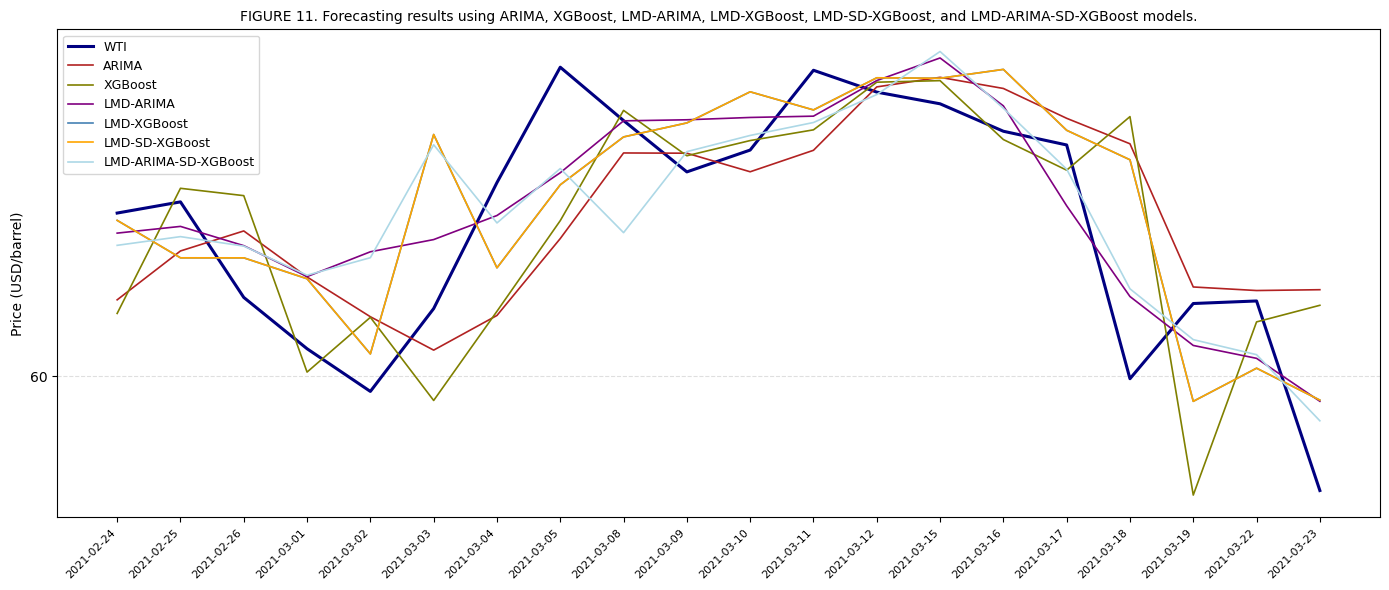

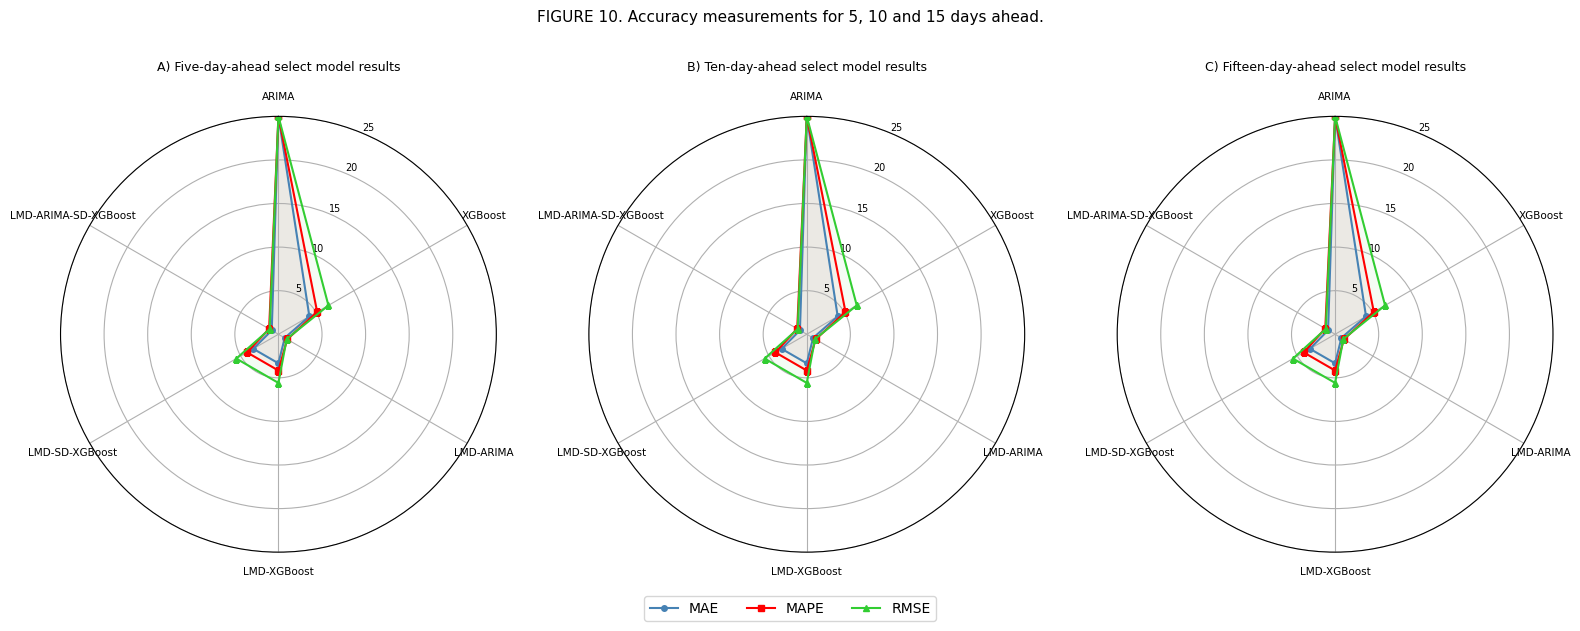

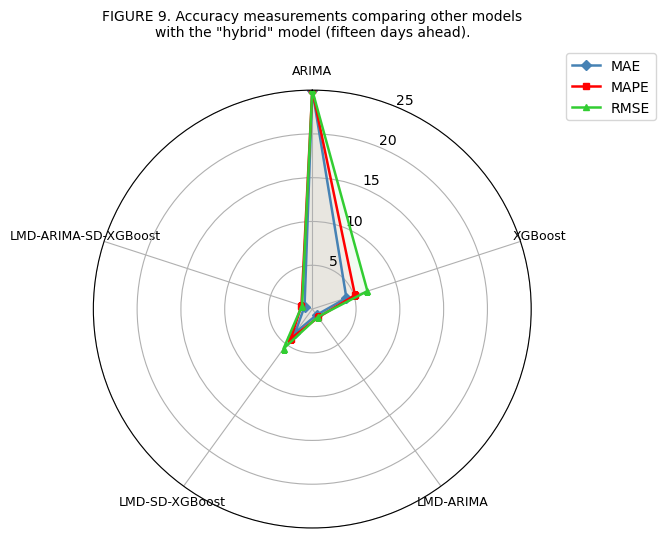

In [16]:
import matplotlib.ticker as mticker


#  Figure 11: Forecast line plot (first 20 test obs, 5-day horizon) 
N_SHOW     = 20
preds_5    = table3_data[5]
show_dates = pd.to_datetime(
    df_paper[df_paper['Date'] >= '2021-02-24']['Date'].values[:N_SHOW])
show_dates_str = [str(d.date()) for d in show_dates]

fig, ax = plt.subplots(figsize=(14, 6))

plot_data = {
    'WTI':                  actual_test[:N_SHOW],
    'ARIMA':                preds_5['ARIMA'][:N_SHOW],
    'XGBoost':              preds_5['XGBoost'][:N_SHOW],
    'LMD-ARIMA':            preds_5['LMD-ARIMA'][:N_SHOW],
    'LMD-XGBoost':          preds_5['LMD-XGBoost'][:N_SHOW],
    'LMD-SD-XGBoost':       preds_5['LMD-SD-XGBoost'][:N_SHOW],
    'LMD-ARIMA-SD-XGBoost': preds_5['LMD-ARIMA-SD-XGBoost'][:N_SHOW],
}
colors = ['navy','firebrick','olive','purple','steelblue','orange','lightblue']

for (name, vals), color in zip(plot_data.items(), colors):
    lw = 2.2 if name == 'WTI' else 1.2
    ax.plot(range(N_SHOW), vals, label=name, color=color, linewidth=lw)

ax.set_xticks(range(N_SHOW))
ax.set_xticklabels(show_dates_str, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.set_ylabel('Price (USD/barrel)')
ax.set_title('FIGURE 11. Forecasting results using ARIMA, XGBoost, LMD-ARIMA, '
             'LMD-XGBoost, LMD-SD-XGBoost, and LMD-ARIMA-SD-XGBoost models.',
             fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()


#  Figures 9 & 10: Radar charts 
model_names_radar = ['ARIMA','XGBoost','LMD-ARIMA',
                     'LMD-XGBoost','LMD-SD-XGBoost','LMD-ARIMA-SD-XGBoost']

def get_metrics_for_radar(preds_dict, actual):
    out = {}
    for name in model_names_radar:
        m = all_metrics(actual, preds_dict[name])
        out[name] = m
    return out

def radar_chart(ax, metrics_dict, title, max_val=25):
    labels   = model_names_radar
    N        = len(labels)
    angles   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles  += angles[:1]   # close the polygon

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=7.5)

    for metric, color, marker in [('MAE','steelblue','o'),
                                   ('MAPE','red','s'),
                                   ('RMSE','limegreen','^')]:
        values = [min(metrics_dict[m][metric], max_val) for m in labels]
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=1.5,
                marker=marker, markersize=4, label=metric)
        ax.fill(angles, values, color=color, alpha=0.05)

    ax.set_ylim(0, max_val)
    ax.set_yticks([5, 10, 15, 20, 25])
    ax.set_yticklabels(['5','10','15','20','25'], fontsize=7)
    ax.set_title(title, size=9, pad=15)


#  Figure 10: All 3 horizons on one radar (A/B/C panels) 
fig, axes = plt.subplots(1, 3, figsize=(16, 6),
                         subplot_kw=dict(polar=True))

for ax, (h, label) in zip(axes, [(5,'A) Five-day-ahead select model results'),
                                   (10,'B) Ten-day-ahead select model results'),
                                   (15,'C) Fifteen-day-ahead select model results')]):
    m = get_metrics_for_radar(table3_data[h], actual_test)
    radar_chart(ax, m, label)

# shared legend
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('FIGURE 10. Accuracy measurements for 5, 10 and 15 days ahead.',
             fontsize=11, y=1.01)
plt.tight_layout()

plt.show()


#  Figure 9: Single radar for 15-day horizon (hybrid model focus) 
fig9, ax9 = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
m15 = get_metrics_for_radar(table3_data[15], actual_test)

# Fig 9 only shows 5 models (paper excludes LMD-XGBoost from Fig 9)
model_names_fig9 = ['ARIMA','XGBoost','LMD-ARIMA',
                    'LMD-SD-XGBoost','LMD-ARIMA-SD-XGBoost']
N9      = len(model_names_fig9)
angles9 = np.linspace(0, 2*np.pi, N9, endpoint=False).tolist()
angles9 += angles9[:1]

ax9.set_theta_offset(np.pi / 2)
ax9.set_theta_direction(-1)
ax9.set_thetagrids(np.degrees(angles9[:-1]), model_names_fig9, fontsize=9)

for metric, color, marker in [('MAE','steelblue','D'),
                                ('MAPE','red','s'),
                                ('RMSE','limegreen','^')]:
    values = [min(m15[m][metric], 25) for m in model_names_fig9]
    values += values[:1]
    ax9.plot(angles9, values, color=color, linewidth=1.8,
             marker=marker, markersize=5, label=metric)
    ax9.fill(angles9, values, color=color, alpha=0.06)

ax9.set_ylim(0, 25)
ax9.set_yticks([5, 10, 15, 20, 25])
ax9.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax9.set_title('FIGURE 9. Accuracy measurements comparing other models\n'
              'with the "hybrid" model (fifteen days ahead).', size=10, pad=20)
plt.tight_layout()

plt.show()